In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/International sale Report.csv', encoding='unicode_escape')
sns.set_theme(style="whitegrid")

print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"Columns: {list(df.columns)}")
df.head()

Rows: 37432, Columns: 10
Columns: ['index', 'DATE', 'Months', 'CUSTOMER', 'Style', 'SKU', 'Size', 'PCS', 'RATE', 'GROSS AMT']


,index,DATE,Months,CUSTOMER,Style,SKU,Size,PCS,RATE,GROSS AMT
0,0,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5004,MEN5004-KR-L,L,1.00,616.56,617.00
1,1,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5004,MEN5004-KR-XL,XL,1.00,616.56,617.00
2,2,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5004,MEN5004-KR-XXL,XXL,1.00,616.56,617.00
3,3,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5009,MEN5009-KR-L,L,1.00,616.56,617.00
4,4,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5011,MEN5011-KR-L,L,1.00,616.56,617.00


In [3]:
# Cell 2 — Cleaning
df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')
df['GROSS AMT'] = pd.to_numeric(df['GROSS AMT'], errors='coerce')
df.dropna(subset=['GROSS AMT'], inplace=True)
print(f"Cleaned Rows: {len(df)}")

Cleaned Rows: 36391


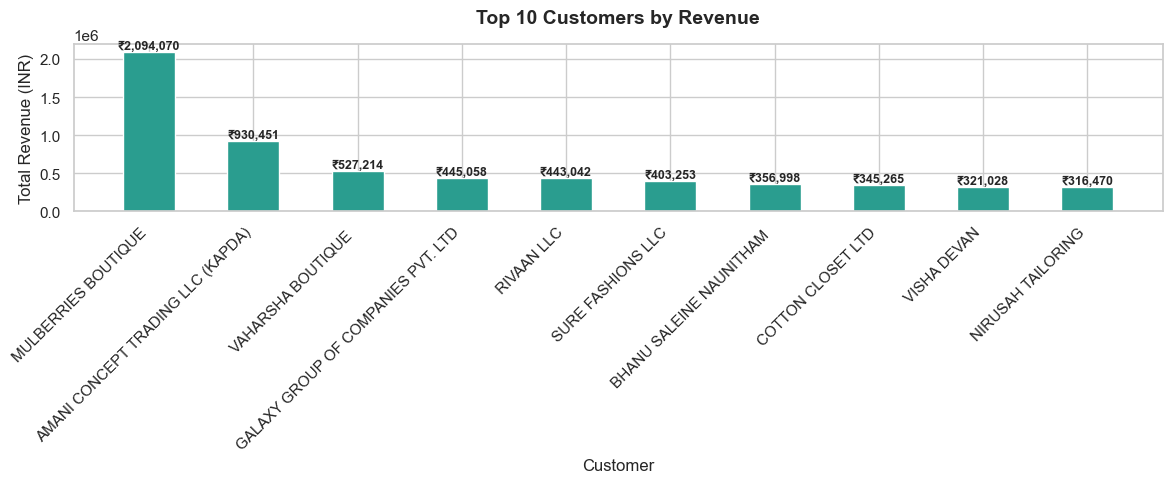

In [4]:
# Cell 3 — Top 10 Customers by Revenue
top_customers = df.groupby('CUSTOMER')['GROSS AMT'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(top_customers.index, top_customers.values,
              color='#2A9D8F', edgecolor='white', width=0.5)

for bar, val in zip(bars, top_customers.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'₹{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Top 10 Customers by Revenue', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Total Revenue (INR)')
ax.set_xlabel('Customer')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/chart_top_customers.png', dpi=150)
plt.show()

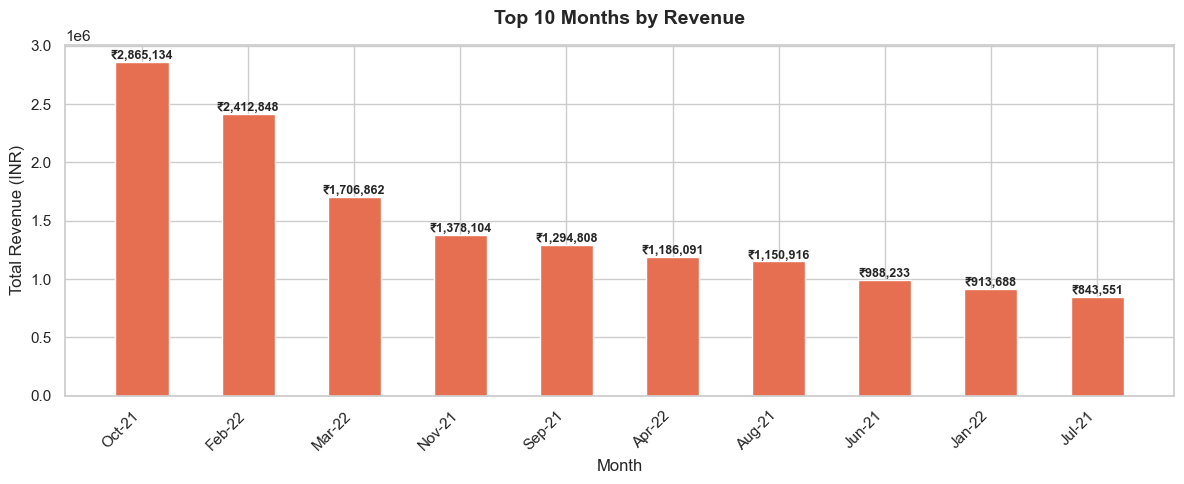

In [5]:
# Cell 4 — Monthly Revenue Trend
monthly = df.groupby('Months')['GROSS AMT'].sum().reset_index()
monthly = monthly.sort_values('GROSS AMT', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(monthly['Months'], monthly['GROSS AMT'],
              color='#E76F51', edgecolor='white', width=0.5)

for bar, val in zip(bars, monthly['GROSS AMT']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'₹{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Top 10 Months by Revenue', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Total Revenue (INR)')
ax.set_xlabel('Month')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/chart_international_monthly.png', dpi=150)
plt.show()

In [6]:
# Cell 5 — Summary
print("=== International Sales Summary ===\n")
print(f"Total Orders: {len(df):,}")
print(f"Total Revenue: ₹{df['GROSS AMT'].sum():,.2f}")
print(f"Avg Order Value: ₹{df['GROSS AMT'].mean():,.2f}")
print(f"Top Customer: {df.groupby('CUSTOMER')['GROSS AMT'].sum().idxmax()}")
print(f"Top Month: {df.groupby('Months')['GROSS AMT'].sum().idxmax()}")
print(f"Top Style: {df.groupby('Style')['GROSS AMT'].sum().idxmax()}")

=== International Sales Summary ===

Total Orders: 36,391
Total Revenue: ₹16,395,599.19
Avg Order Value: ₹450.54
Top Customer: MULBERRIES BOUTIQUE
Top Month: Oct-21
Top Style: SET268
